# Chapter 2: The Cech-de Rham Complex

**Source Span.** `Differential Forms in Algebraic Topology.pdf`, printed pages `89-153` (PDF page labels `89-153`; physical extraction pages `100-164` in this copy).

**Chapter Goal.** Turn the chapter's tic-tac-toe arguments into inspectable finite models: the Cech-de Rham double complex, the sign-corrected total differential, good-cover nerves, collating from Cech cocycles to forms, sphere-bundle Euler obstructions, Thom classes, compact-support duality, and monodromy of locally constant presheaves.

The guiding question is: **when can local differential-form data be assembled into a global invariant, and what obstruction appears when assembly fails?** The chapter answers this repeatedly. Exact Cech rows give the generalized Mayer-Vietoris principle. Exact columns for a good cover identify de Rham cohomology with Cech cohomology. Sphere bundles replace the same grid by a zig-zag whose final unresolved edge is the Euler class. Thom and Poincare duality use the compact-support version of the same game. Monodromy explains why a locally constant presheaf need not become a constant one unless loops in the nerve act trivially.


## Visual Storyboard

1. **Total-complex sign rule.** A Plotly grid and an exact SymPy matrix check show why `D = delta + (-1)^p d` squares to zero while the naive sum does not.
2. **Proof dependency map.** A directed graph tracks which exactness inputs feed the Cech-de Rham comparison, the good-cover comparison, the sphere-bundle Euler obstruction, Thom isomorphism, Poincare duality, and monodromy.
3. **Good-cover nerves.** The circle and sphere examples are computed as finite simplicial complexes; the visible nerve and boundary ranks produce the expected Betti numbers.
4. **Collating formula model.** A generator of Cech `H^1` on a circle cover is shown as a normalized bump 1-form with period one, the computational shadow of the partition-of-unity collating formula.
5. **Presheaf monodromy.** Matrix actions around a loop show how a locally constant presheaf can fail to be constant, and how fixed vectors/cokernels become local-system cohomology.
6. **Sphere-bundle Euler obstruction.** A tic-tac-toe descent diagram marks the obstruction class; a local-degree model for `S(TS^2)` verifies Euler number `2`.
7. **Thom and compact duality.** A radial cutoff diagram makes the Thom form support visible, and a final check ties the zero-section pullback to the Euler class model.

Every generated artifact is saved under `artifacts/chapter-02-the-cech-de-rham-complex/` and displayed near the concept it supports.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

try:
    import gudhi as gd
except Exception as exc:
    gd = None
    print(f"Gudhi unavailable; falling back to exact boundary matrices: {exc}")

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Forms in Algebraic Topology book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-02-the-cech-de-rham-complex"
UNIT_TITLE = "The Cech-de Rham Complex"
SOURCE_SPAN = "printed pages 89-153"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

ARTIFACTS = {}
CHECK_DATA = {}

def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Book root: D:\Geometry\Differential-Forms-in-Algebraic-Topology
Artifact root: artifacts/chapter-02-the-cech-de-rham-complex


## Computational Translation Guide

The chapter's objects are infinite-dimensional when read literally: forms on every open set, restrictions over all intersections, compactly supported vertical forms, and presheaves over refinements. The notebook uses finite models that preserve the algebraic moves the proofs need.

| Book language | Computational model used here | Inspection target |
| --- | --- | --- |
| `C^p(U, Omega^q)` | grid node at bidegree `(p,q)` | which direction is `delta`, which is `d`, and where signs enter |
| total differential `D` | exact matrices on a small double complex | `D^2 = 0`, while `delta + d` fails |
| good cover | finite nerve complex | Betti numbers from boundary ranks |
| partition of unity homotopy `K` | normalized bump form from a Cech cocycle | period of the resulting 1-form |
| sphere-bundle orientation data | diagonal extension problem in a double complex | final obstruction is the Euler class |
| Thom form | compact radial cutoff times angular data | support near the zero section and pullback behavior |
| locally constant presheaf | matrices on nerve edges | loop product is monodromy |


## Library Routing

The chapter is primarily topology plus exterior-form bookkeeping, so the computation routes through finite complexes and exact symbolic matrices. Matplotlib is used for durable static proof diagrams; Plotly is used where the total-complex grid benefits from hoverable bidegree labels. Gudhi is used as a topology library for the nerve complexes, with exact SymPy boundary matrices kept visible so the algebra does not disappear into a black box.


In [2]:
routing_rows = [
    {
        "concept": "Cech-de Rham total differential",
        "representation": "bidegree grid plus exact matrices",
        "library": "Plotly, SymPy",
        "why": "Plotly exposes the double-complex geometry; SymPy proves the sign-corrected composition exactly.",
        "artifact": "html/cech-de-rham-total-complex.html; checks/total-differential-sign-check.json",
        "validation": "signed D^2 is zero; naive (delta+d)^2 is not zero",
    },
    {
        "concept": "good-cover Cech cohomology",
        "representation": "circle and sphere nerves with boundary matrices",
        "library": "Gudhi, SymPy, Matplotlib",
        "why": "Gudhi models simplicial nerves; exact matrices make coboundary ranks auditable.",
        "artifact": "figures/good-cover-nerve-cohomology.png; checks/nerve-cohomology-checks.json",
        "validation": "circle Betti numbers [1,1]; sphere Betti numbers [1,0,1]; boundary squared is zero",
    },
    {
        "concept": "collating Cech cocycles to de Rham forms",
        "representation": "period-one bump 1-form on a circle cover",
        "library": "NumPy, Matplotlib, SymPy",
        "why": "A one-dimensional form makes the collating formula's period visible and measurable.",
        "artifact": "figures/collating-circle-cocycle-form.png; checks/collating-circle-cocycle-checks.json",
        "validation": "cocycle is not a coboundary; collated density integrates to 1",
    },
    {
        "concept": "monodromy of locally constant presheaves",
        "representation": "edge matrices on the nerve loop",
        "library": "NetworkX, NumPy, SymPy, Matplotlib",
        "why": "The obstruction is a loop action; matrices expose fixed vectors and cokernels.",
        "artifact": "figures/monodromy-local-system-loop.png; checks/monodromy-local-system-checks.json",
        "validation": "cohomology dimensions are computed from rank(P-I)",
    },
    {
        "concept": "sphere-bundle Euler obstruction",
        "representation": "tic-tac-toe extension diagram and local degree field",
        "library": "NetworkX, NumPy, Matplotlib",
        "why": "The obstruction is a terminal node in the same double-complex descent; local degree is geometric winding.",
        "artifact": "figures/sphere-bundle-euler-obstruction.png; figures/euler-local-degree-s2.png",
        "validation": "degree(z -> z^2) = 2 = chi(S^2)",
    },
    {
        "concept": "Thom class and Poincare duality revisited",
        "representation": "radial cutoff support and compact-support check",
        "library": "NumPy, Matplotlib, SymPy",
        "why": "The Thom form is a compactly supported radial construction; the cutoff makes support control inspectable.",
        "artifact": "figures/thom-cutoff-support.png; checks/thom-poincare-checks.json",
        "validation": "integral of dp is 1 and zero-section pullback symbolically returns e",
    },
]
routing_path = TABLES / "the-cech-de-rham-complex-routing.csv"
save_csv(routing_rows, routing_path)
ARTIFACTS["routing_table"] = routing_path
pd.DataFrame(routing_rows)


,concept,representation,library,why,artifact,validation
0,Cech-de Rham total differential,bidegree grid plus exact matrices,"Plotly, SymPy",Plotly exposes the double-complex geometry; Sy...,html/cech-de-rham-total-complex.html; checks/t...,signed D^2 is zero; naive (delta+d)^2 is not zero
1,good-cover Cech cohomology,circle and sphere nerves with boundary matrices,"Gudhi, SymPy, Matplotlib",Gudhi models simplicial nerves; exact matrices...,figures/good-cover-nerve-cohomology.png; check...,"circle Betti numbers [1,1]; sphere Betti numbe..."
2,collating Cech cocycles to de Rham forms,period-one bump 1-form on a circle cover,"NumPy, Matplotlib, SymPy",A one-dimensional form makes the collating for...,figures/collating-circle-cocycle-form.png; che...,cocycle is not a coboundary; collated density ...
3,monodromy of locally constant presheaves,edge matrices on the nerve loop,"NetworkX, NumPy, SymPy, Matplotlib",The obstruction is a loop action; matrices exp...,figures/monodromy-local-system-loop.png; check...,cohomology dimensions are computed from rank(P-I)
4,sphere-bundle Euler obstruction,tic-tac-toe extension diagram and local degree...,"NetworkX, NumPy, Matplotlib",The obstruction is a terminal node in the same...,figures/sphere-bundle-euler-obstruction.png; f...,degree(z -> z^2) = 2 = chi(S^2)
5,Thom class and Poincare duality revisited,radial cutoff support and compact-support check,"NumPy, Matplotlib, SymPy",The Thom form is a compactly supported radial ...,figures/thom-cutoff-support.png; checks/thom-p...,integral of dp is 1 and zero-section pullback ...


## 1. The Total Complex: Why the Sign Is Not Cosmetic

For a cover `U`, the Cech-de Rham groups sit in bidegrees `C^p(U, Omega^q)`. The horizontal operator is the alternating Cech coboundary `delta`; the vertical operator is the exterior derivative `d`. These commute before totalization. To make a single complex, the vertical part must acquire a column sign: on column `p`, use `(-1)^p d`. Then each square anticommutes in the total complex, so the two routes across a square cancel.

The plot marks the anti-diagonal summing convention. The exact matrix check below is intentionally small, but it captures the chapter's core bookkeeping: the proof is not a drawing convention; it is the algebraic reason the total differential is a differential.


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


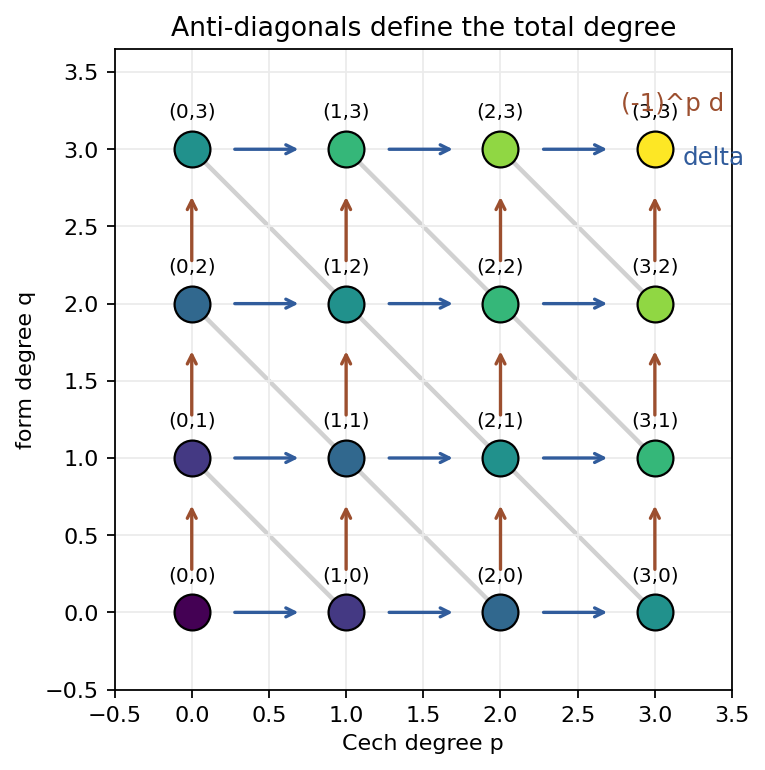

In [3]:
# Tensor-product toy double complex: horizontal and vertical maps square to zero before totalization.
H_dims = [1, 2, 1]
V_dims = [1, 2, 1]
H_delta = [sp.Matrix([[1], [-1]]), sp.Matrix([[1, 1]])]
V_d = [sp.Matrix([[1], [-1]]), sp.Matrix([[1, 1]])]
assert H_delta[1] * H_delta[0] == sp.zeros(1, 1)
assert V_d[1] * V_d[0] == sp.zeros(1, 1)

bidegree_blocks = {
    n: [(p, n - p) for p in range(3) if 0 <= n - p <= 2]
    for n in range(5)
}

def block_offsets(blocks):
    offsets = {}
    cursor = 0
    for b in blocks:
        p, q = b
        offsets[b] = cursor
        cursor += H_dims[p] * V_dims[q]
    return offsets, cursor

def place_block(big, row0, col0, block):
    for i in range(block.rows):
        for j in range(block.cols):
            big[row0 + i, col0 + j] += block[i, j]

def total_matrix(n: int, *, signed: bool) -> sp.Matrix:
    cols = bidegree_blocks.get(n, [])
    rows = bidegree_blocks.get(n + 1, [])
    col_offsets, col_dim = block_offsets(cols)
    row_offsets, row_dim = block_offsets(rows)
    mat = sp.zeros(row_dim, col_dim)
    for p, q in cols:
        col0 = col_offsets[(p, q)]
        if p < 2 and (p + 1, q) in row_offsets:
            block = sp.kronecker_product(H_delta[p], sp.eye(V_dims[q]))
            place_block(mat, row_offsets[(p + 1, q)], col0, block)
        if q < 2 and (p, q + 1) in row_offsets:
            sign = (-1) ** p if signed else 1
            block = sign * sp.kronecker_product(sp.eye(H_dims[p]), V_d[q])
            place_block(mat, row_offsets[(p, q + 1)], col0, block)
    return mat

signed_compositions = [total_matrix(n + 1, signed=True) * total_matrix(n, signed=True) for n in range(4)]
naive_compositions = [total_matrix(n + 1, signed=False) * total_matrix(n, signed=False) for n in range(4)]
signed_zero = all(mat == sp.zeros(*mat.shape) for mat in signed_compositions)
naive_nonzero_entries = sum(1 for mat in naive_compositions for value in list(mat) if value != 0)
assert signed_zero
assert naive_nonzero_entries > 0

sign_check = {
    "horizontal_dims": H_dims,
    "vertical_dims": V_dims,
    "horizontal_delta_squared_zero": H_delta[1] * H_delta[0] == sp.zeros(1, 1),
    "vertical_d_squared_zero": V_d[1] * V_d[0] == sp.zeros(1, 1),
    "bidegrees_by_total_degree": {str(k): [list(x) for x in v] for k, v in bidegree_blocks.items()},
    "signed_D_squared_zero": signed_zero,
    "naive_nonzero_entries_in_D_squared": naive_nonzero_entries,
}
sign_check_path = CHECKS / "total-differential-sign-check.json"
save_json(sign_check, sign_check_path)
ARTIFACTS["total_sign_check"] = sign_check_path
CHECK_DATA["total_sign_check"] = sign_check

points = [(p, q) for p in range(4) for q in range(4)]
fig = go.Figure()
for total_degree in range(7):
    diag = [(p, q) for p, q in points if p + q == total_degree]
    if len(diag) >= 2:
        fig.add_trace(go.Scatter(x=[p for p, _ in diag], y=[q for _, q in diag], mode="lines", line=dict(color="rgba(70,70,70,0.25)", width=2), hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(
    x=[p for p, _ in points], y=[q for _, q in points], mode="markers+text",
    marker=dict(size=18, color=[p + q for p, q in points], colorscale="Viridis", showscale=False),
    text=[f"C^{p},Omega^{q}" for p, q in points], textposition="top center",
    hovertext=[f"bidegree ({p},{q}); total degree {p+q}; vertical sign (-1)^{p}" for p, q in points], hoverinfo="text", showlegend=False,
))
for p0, q0 in points:
    if p0 < 3:
        fig.add_annotation(x=p0 + 0.82, y=q0, ax=p0 + 0.18, ay=q0, xref="x", yref="y", axref="x", ayref="y", showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=1.4, arrowcolor="#315c9c", text="")
    if q0 < 3:
        fig.add_annotation(x=p0, y=q0 + 0.82, ax=p0, ay=q0 + 0.18, xref="x", yref="y", axref="x", ayref="y", showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=1.4, arrowcolor="#9c4f2f", text="")
fig.update_layout(title="Cech-de Rham double complex: horizontal delta, vertical signed d", xaxis=dict(title="Cech degree p", dtick=1, range=[-0.4, 3.4]), yaxis=dict(title="form degree q", dtick=1, range=[-0.4, 3.6]), width=900, height=560, plot_bgcolor="white")
total_complex_html = HTML / "cech-de-rham-total-complex.html"
save_plotly_html(fig, total_complex_html)
ARTIFACTS["total_complex_html"] = total_complex_html
display_artifact(total_complex_html, width=900, height=560)

fig2, ax = plt.subplots(figsize=(7.5, 5.2))
for total_degree in range(7):
    diag = np.array([(p, q) for p, q in points if p + q == total_degree])
    if len(diag) > 1:
        ax.plot(diag[:, 0], diag[:, 1], color="0.82", lw=2, zorder=0)
for p0, q0 in points:
    ax.scatter(p0, q0, s=260, color=plt.cm.viridis((p0 + q0) / 6), edgecolor="black", zorder=3)
    ax.text(p0, q0 + 0.18, f"({p0},{q0})", ha="center", va="bottom", fontsize=9)
    if p0 < 3:
        ax.annotate("", xy=(p0 + 0.72, q0), xytext=(p0 + 0.25, q0), arrowprops=dict(arrowstyle="->", color="#315c9c", lw=1.5))
    if q0 < 3:
        ax.annotate("", xy=(p0, q0 + 0.72), xytext=(p0, q0 + 0.25), arrowprops=dict(arrowstyle="->", color="#9c4f2f", lw=1.5))
ax.text(3.18, 2.9, "delta", color="#315c9c", fontsize=11)
ax.text(2.78, 3.25, "(-1)^p d", color="#9c4f2f", fontsize=11)
ax.set_xlabel("Cech degree p")
ax.set_ylabel("form degree q")
ax.set_title("Anti-diagonals define the total degree")
ax.set_aspect("equal")
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.65)
ax.grid(True, color="0.92")
static_total_path = FIGURES / "cech-de-rham-total-complex-sign-rule.png"
save_matplotlib(fig2, static_total_path)
plt.close(fig2)
ARTIFACTS["total_complex_static"] = static_total_path
display_artifact(static_total_path, width=760)


## 2. The Tic-Tac-Toe Proof Map

The chapter uses one proof machine many times. If the rows of an augmented double complex are exact, a cocycle can be pushed across the board until it lives in the initial column. If the columns are exact, it can be pushed toward the bottom row. A good cover activates both stories: row exactness compares de Rham cohomology with total Cech-de Rham cohomology, and column exactness compares total cohomology with the Cech cohomology of the nerve.

For sphere bundles the same tic-tac-toe movement becomes obstruction theory: one tries to extend local fiber volume classes diagonally downward. The final edge that refuses to close is the Euler class. Thom isomorphism and Poincare duality repeat the game with compact vertical support and compact support on the base.


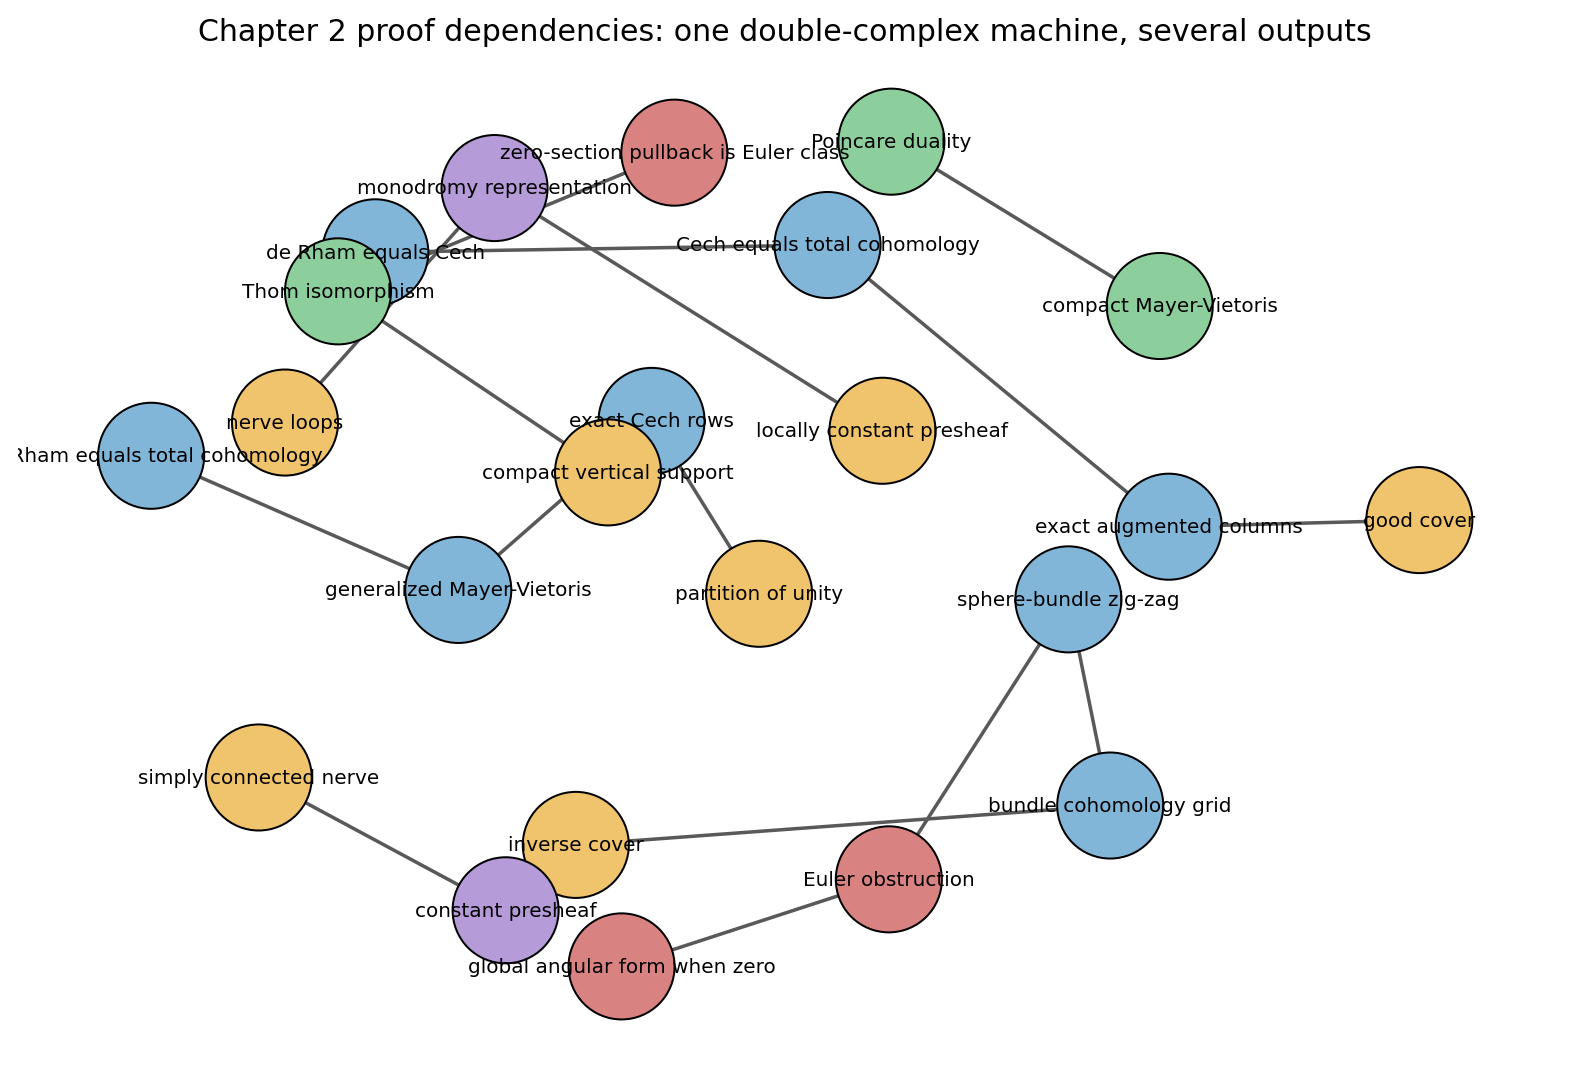

In [4]:
proof_edges = [
    ("partition of unity", "exact Cech rows"),
    ("exact Cech rows", "generalized Mayer-Vietoris"),
    ("generalized Mayer-Vietoris", "de Rham equals total cohomology"),
    ("good cover", "exact augmented columns"),
    ("exact augmented columns", "Cech equals total cohomology"),
    ("Cech equals total cohomology", "de Rham equals Cech"),
    ("inverse cover", "bundle cohomology grid"),
    ("bundle cohomology grid", "sphere-bundle zig-zag"),
    ("sphere-bundle zig-zag", "Euler obstruction"),
    ("Euler obstruction", "global angular form when zero"),
    ("compact vertical support", "Thom isomorphism"),
    ("Thom isomorphism", "zero-section pullback is Euler class"),
    ("compact Mayer-Vietoris", "Poincare duality"),
    ("locally constant presheaf", "monodromy representation"),
    ("nerve loops", "monodromy representation"),
    ("simply connected nerve", "constant presheaf"),
]
G = nx.DiGraph()
G.add_edges_from(proof_edges)
proof_pos = nx.spring_layout(G, seed=11, k=0.85)
fig, ax = plt.subplots(figsize=(11, 7.2))
role_color = {"input": "#f0c36d", "comparison": "#82b6d9", "obstruction": "#d98282", "duality": "#8ccf9c", "monodromy": "#b59bd8"}
node_roles = {}
for node in G.nodes:
    if node in {"partition of unity", "good cover", "inverse cover", "compact vertical support", "locally constant presheaf", "nerve loops", "simply connected nerve"}:
        node_roles[node] = "input"
    elif node in {"Euler obstruction", "global angular form when zero", "zero-section pullback is Euler class"}:
        node_roles[node] = "obstruction"
    elif node in {"Thom isomorphism", "Poincare duality", "compact Mayer-Vietoris"}:
        node_roles[node] = "duality"
    elif node in {"monodromy representation", "constant presheaf"}:
        node_roles[node] = "monodromy"
    else:
        node_roles[node] = "comparison"
colors = [role_color[node_roles[n]] for n in G.nodes]
nx.draw_networkx_edges(G, proof_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.4, edge_color="0.35")
nx.draw_networkx_nodes(G, proof_pos, ax=ax, node_size=1800, node_color=colors, edgecolors="black", linewidths=0.8)
nx.draw_networkx_labels(G, proof_pos, ax=ax, font_size=8)
ax.set_title("Chapter 2 proof dependencies: one double-complex machine, several outputs")
ax.axis("off")
proof_path = FIGURES / "chapter-02-proof-dependency-map.png"
save_matplotlib(fig, proof_path, dpi=180)
plt.close(fig)
proof_json_path = CHECKS / "chapter-02-proof-dependency-map.json"
proof_summary = {"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G), "sinks": sorted([n for n in G.nodes if G.out_degree(n) == 0])}
save_json(proof_summary, proof_json_path)
ARTIFACTS["proof_map"] = proof_path
ARTIFACTS["proof_map_check"] = proof_json_path
CHECK_DATA["proof_map"] = proof_summary
display_artifact(proof_path, width=880)


## 3. Good Covers and Nerve Cohomology

A good cover lets the continuous problem collapse to combinatorics. The nerve has a vertex for each open set, an edge for a nonempty pairwise intersection, a filled triangle for a nonempty triple intersection, and so on. For a good cover, the augmented columns are exact by the Poincare lemma, so the bottom Cech complex computes de Rham cohomology.

The circle and sphere examples below are finite versions of the chapter's computations. The circle cover has a triangular nerve without the filled face, so it has one 1-cycle. The sphere cover has the boundary of a tetrahedron, so it has a 2-cycle and no 1-cycle.


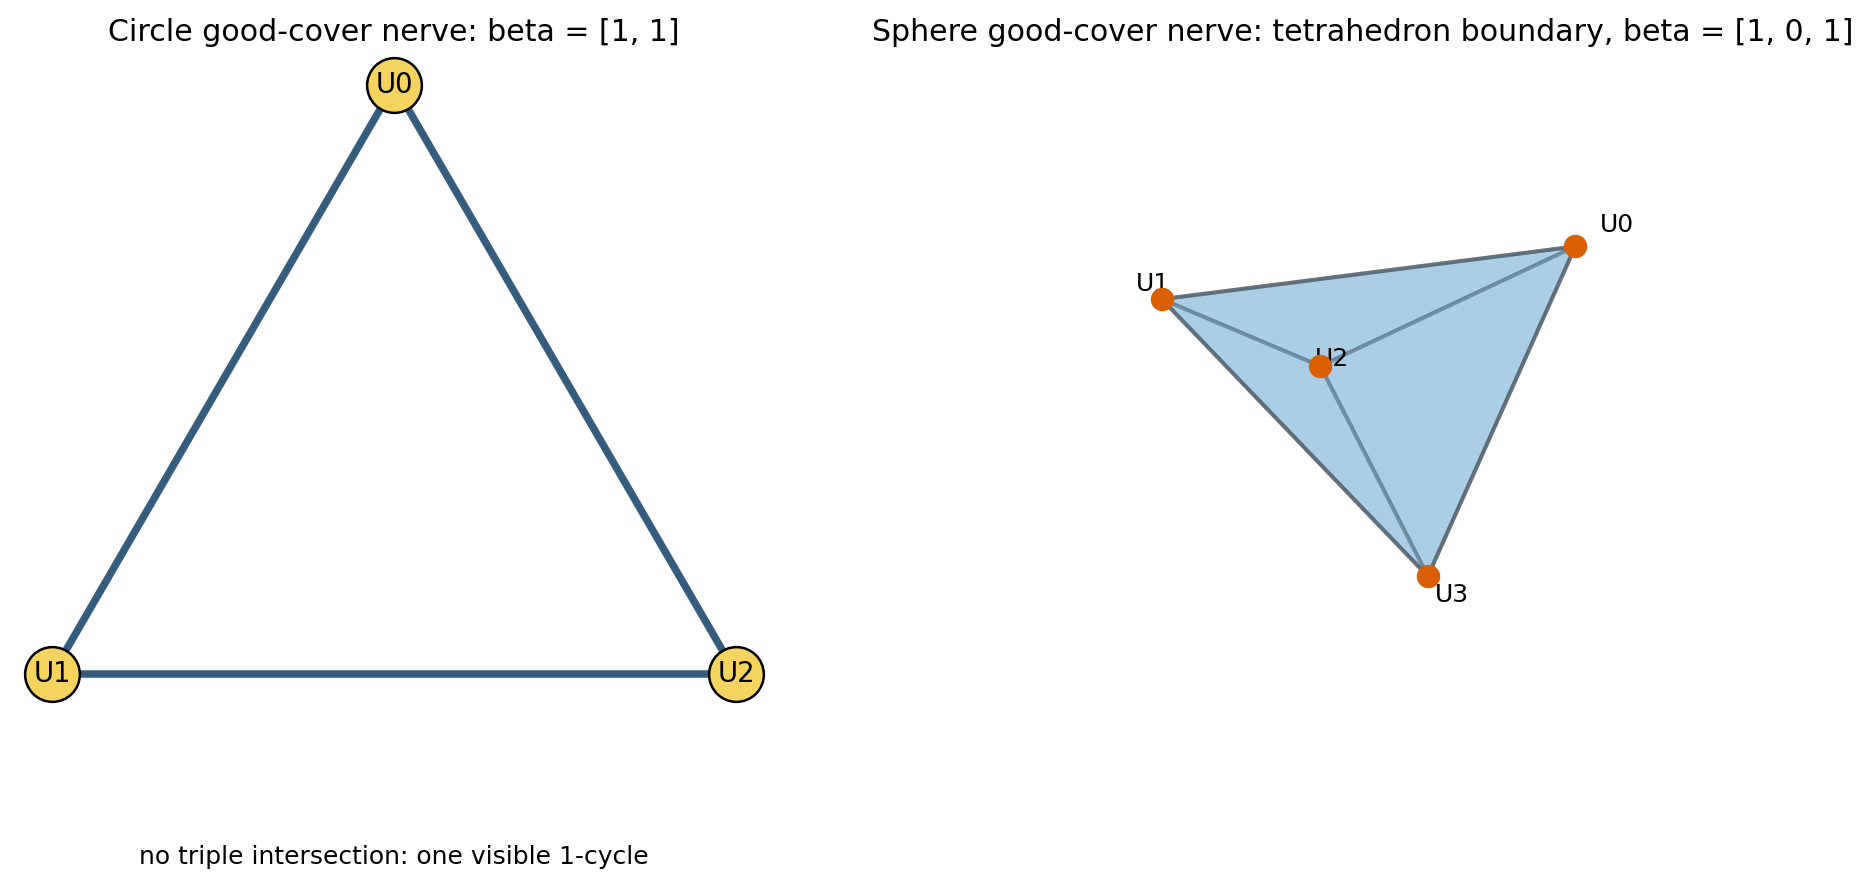

,complex,boundary,rank,domain_dim,target_dim
0,circle nerve,partial_1,2,3,3
1,circle nerve,partial_2,0,0,3
2,sphere nerve,partial_1,3,6,4
3,sphere nerve,partial_2,3,4,6


In [5]:
import itertools

def all_simplices(max_simplices):
    simplices = set()
    for simplex in max_simplices:
        simplex = tuple(sorted(simplex))
        for r in range(1, len(simplex) + 1):
            for face in itertools.combinations(simplex, r):
                simplices.add(face)
    return sorted(simplices, key=lambda s: (len(s), s))

def boundary_matrix(simplices_k, simplices_prev):
    if not simplices_k or not simplices_prev:
        return sp.zeros(len(simplices_prev), len(simplices_k))
    row_index = {s: i for i, s in enumerate(simplices_prev)}
    mat = sp.zeros(len(simplices_prev), len(simplices_k))
    for j, simplex in enumerate(simplices_k):
        for i in range(len(simplex)):
            face = simplex[:i] + simplex[i+1:]
            mat[row_index[face], j] = (-1) ** i
    return mat

def betti_summary(max_simplices, max_dim):
    simplices = all_simplices(max_simplices)
    by_dim = {k: [s for s in simplices if len(s) == k + 1] for k in range(max_dim + 1)}
    boundaries = {}
    ranks = {}
    for k in range(1, max_dim + 1):
        boundaries[k] = boundary_matrix(by_dim[k], by_dim[k-1])
        ranks[k] = int(boundaries[k].rank())
    betti = []
    for k in range(max_dim + 1):
        dim_ck = len(by_dim[k])
        rank_in = ranks.get(k, 0)
        rank_out = ranks.get(k + 1, 0)
        betti.append(dim_ck - rank_in - rank_out)
    boundary_squared_zero = True
    for k in range(2, max_dim + 1):
        boundary_squared_zero = boundary_squared_zero and (boundaries[k-1] * boundaries[k] == sp.zeros(len(by_dim[k-2]), len(by_dim[k])))
    gudhi_betti = None
    if gd is not None:
        st = gd.SimplexTree()
        for simplex in max_simplices:
            st.insert(list(simplex), filtration=0.0)
        st.compute_persistence(persistence_dim_max=True)
        gudhi_betti = [int(x) for x in st.betti_numbers()]
    return {"simplices": by_dim, "boundaries": boundaries, "ranks": ranks, "betti": betti, "boundary_squared_zero": bool(boundary_squared_zero), "gudhi_betti": gudhi_betti}

circle_max = [(0, 1), (1, 2), (0, 2)]
sphere_max = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
circle = betti_summary(circle_max, 2)
sphere = betti_summary(sphere_max, 2)
assert circle["betti"][:2] == [1, 1]
assert sphere["betti"][:3] == [1, 0, 1]
assert circle["boundary_squared_zero"] and sphere["boundary_squared_zero"]

rank_rows = []
for name, summary in [("circle nerve", circle), ("sphere nerve", sphere)]:
    for k in range(1, 3):
        rank_rows.append({"complex": name, "boundary": f"partial_{k}", "rank": summary["ranks"].get(k, 0), "domain_dim": len(summary["simplices"].get(k, [])), "target_dim": len(summary["simplices"].get(k-1, []))})
rank_table_path = TABLES / "nerve-boundary-ranks.csv"
save_csv(rank_rows, rank_table_path)
ARTIFACTS["nerve_rank_table"] = rank_table_path

nerve_check = {
    "circle": {"simplex_counts": {str(k): len(v) for k, v in circle["simplices"].items()}, "betti_exact": circle["betti"], "betti_gudhi": circle["gudhi_betti"], "boundary_squared_zero": circle["boundary_squared_zero"]},
    "sphere": {"simplex_counts": {str(k): len(v) for k, v in sphere["simplices"].items()}, "betti_exact": sphere["betti"], "betti_gudhi": sphere["gudhi_betti"], "boundary_squared_zero": sphere["boundary_squared_zero"]},
}
nerve_check_path = CHECKS / "nerve-cohomology-checks.json"
save_json(nerve_check, nerve_check_path)
ARTIFACTS["nerve_check"] = nerve_check_path
CHECK_DATA["nerve"] = nerve_check

fig = plt.figure(figsize=(11, 4.8))
ax1 = fig.add_subplot(1, 2, 1)
tri_pos = {0: np.array([0.0, 1.0]), 1: np.array([-0.9, -0.55]), 2: np.array([0.9, -0.55])}
for a, b in circle_max:
    ax1.plot([tri_pos[a][0], tri_pos[b][0]], [tri_pos[a][1], tri_pos[b][1]], color="#355c7d", lw=3)
for node, xy in tri_pos.items():
    ax1.scatter(*xy, s=480, color="#f4d35e", edgecolor="black", zorder=3)
    ax1.text(*xy, f"U{node}", ha="center", va="center", fontsize=11)
ax1.text(0, -1.05, "no triple intersection: one visible 1-cycle", ha="center", fontsize=10)
ax1.set_title("Circle good-cover nerve: beta = [1, 1]")
ax1.set_aspect("equal")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
tet = np.array([[1, 1, 1], [-1, -1, 1], [-1, 1, -1], [1, -1, -1]], dtype=float)
faces = [tet[list(face)] for face in sphere_max]
poly = Poly3DCollection(faces, alpha=0.42, facecolor="#82b6d9", edgecolor="#1f2933", linewidth=1.6)
ax2.add_collection3d(poly)
ax2.scatter(tet[:, 0], tet[:, 1], tet[:, 2], s=70, color="#d95f02", depthshade=False)
for i, xyz in enumerate(tet):
    ax2.text(*(xyz * 1.12), f"U{i}", fontsize=10)
ax2.set_title("Sphere good-cover nerve: tetrahedron boundary, beta = [1, 0, 1]")
ax2.set_xlim(-1.4, 1.4); ax2.set_ylim(-1.4, 1.4); ax2.set_zlim(-1.4, 1.4)
ax2.set_axis_off()
fig.tight_layout()
nerve_path = FIGURES / "good-cover-nerve-cohomology.png"
save_matplotlib(fig, nerve_path, dpi=180)
plt.close(fig)
ARTIFACTS["nerve_figure"] = nerve_path
display_artifact(nerve_path, width=900)
pd.DataFrame(rank_rows)


## 4. Collating a Cech Cocycle into a Global Form

The collating formula is the chapter's explicit bridge from a Cech cocycle to a de Rham representative. The operator `K` uses a partition of unity to lower Cech degree; repeated use of `D''K` turns a Cech `n`-cocycle into a global closed `n`-form.

For the circle cover, a nontrivial Cech 1-cocycle cannot be solved as a Cech coboundary. The visible model below replaces the formula's local bump by a normalized smooth density on the circle. Its integral is one, so it represents the generator of `H^1(S^1)`. The point is not that every generator must look like this density; the point is that the discrete cocycle becomes a measurable de Rham period.


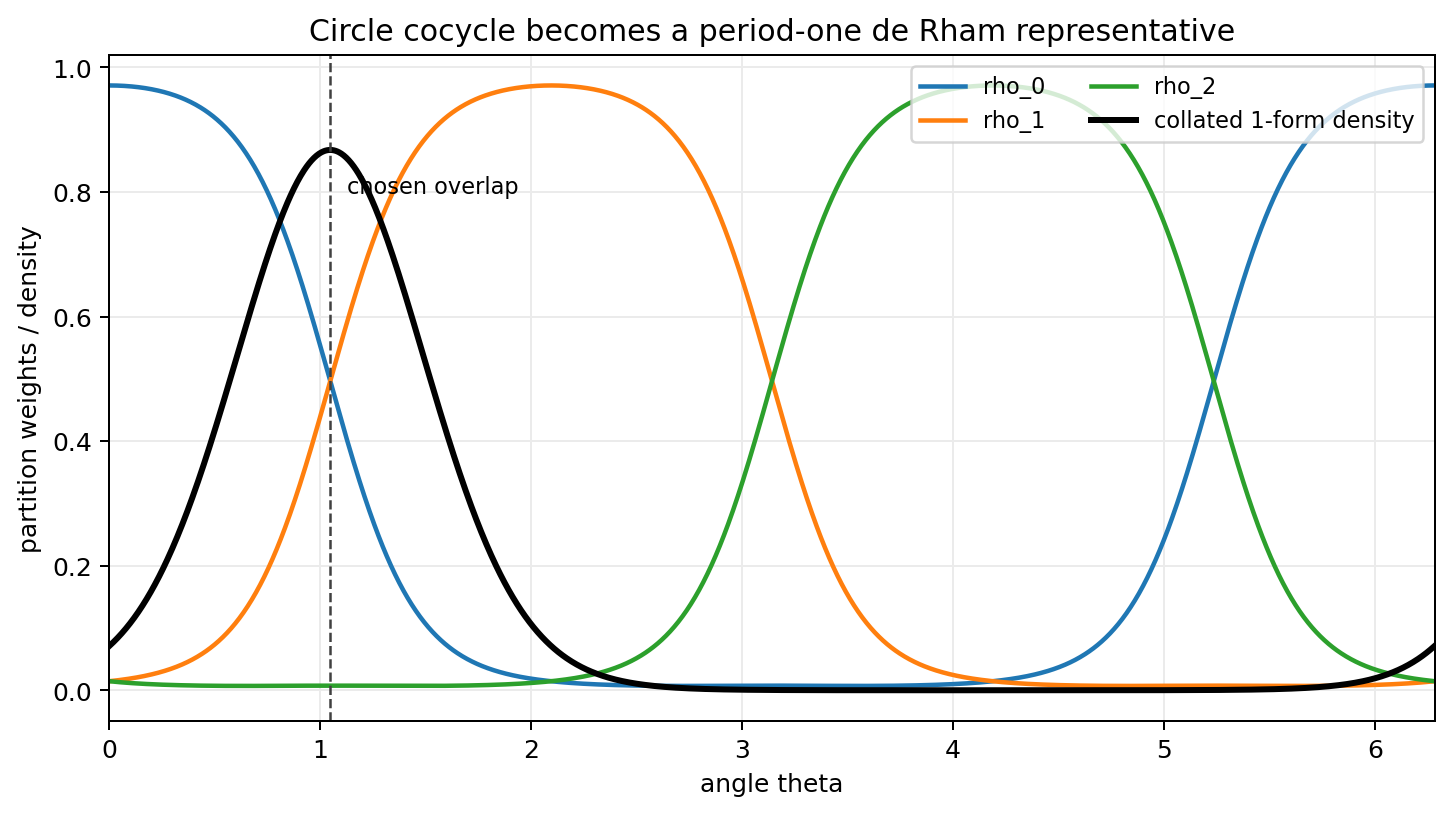

In [6]:
delta0 = sp.Matrix([[-1, 1, 0], [-1, 0, 1], [0, -1, 1]])
eta = sp.Matrix([1, 0, 0])
rank_delta = int(delta0.rank())
rank_augmented = int(delta0.row_join(eta).rank())
not_coboundary = rank_augmented > rank_delta
assert not_coboundary

theta = np.linspace(0, 2 * np.pi, 1600, endpoint=False)
center = np.pi / 3
raw = np.exp(5.0 * np.cos(theta - center))
density = raw / np.trapezoid(raw, theta)
period = float(np.trapezoid(density, theta))
assert abs(period - 1.0) < 5e-4

centers = np.array([0.0, 2*np.pi/3, 4*np.pi/3])
weights_raw = np.vstack([np.exp(2.8 * np.cos(theta - c)) for c in centers])
weights = weights_raw / weights_raw.sum(axis=0, keepdims=True)
partition_error = float(np.max(np.abs(weights.sum(axis=0) - 1)))
assert partition_error < 1e-12

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for i in range(3):
    ax.plot(theta, weights[i], lw=1.8, label=f"rho_{i}")
ax.plot(theta, density, color="black", lw=2.4, label="collated 1-form density")
ax.axvline(center, color="0.25", ls="--", lw=1)
ax.text(center + 0.08, density.max() * 0.92, "chosen overlap", fontsize=9)
ax.set_xlim(0, 2*np.pi)
ax.set_xlabel("angle theta")
ax.set_ylabel("partition weights / density")
ax.set_title("Circle cocycle becomes a period-one de Rham representative")
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.grid(True, color="0.92")
collating_path = FIGURES / "collating-circle-cocycle-form.png"
save_matplotlib(fig, collating_path, dpi=180)
plt.close(fig)

collating_check = {"delta0_rank": rank_delta, "augmented_rank_with_eta": rank_augmented, "eta_is_coboundary": not not_coboundary, "collated_density_period": period, "partition_of_unity_max_error": partition_error, "cech_generator_edges_order": ["01", "02", "12"], "eta": [int(x) for x in eta]}
collating_check_path = CHECKS / "collating-circle-cocycle-checks.json"
save_json(collating_check, collating_check_path)
ARTIFACTS["collating_figure"] = collating_path
ARTIFACTS["collating_check"] = collating_check_path
CHECK_DATA["collating"] = collating_check
display_artifact(collating_path, width=820)


## 5. Presheaves, Refinements, and Monodromy

A presheaf stores data on open sets plus restriction maps. Refinement maps compare Cech complexes for different covers, and homotopies between refinement maps make the direct-limit definition independent of a particular choice. For a locally constant presheaf on a good cover, every restriction is an isomorphism, but the presheaf can still fail to be constant: moving around a loop in the nerve may return by a nontrivial automorphism.

That loop automorphism is monodromy. In the double cover of a circle, the fiber has two points, so `H^0` of the fiber is `R^2`. A trip around the base swaps the two basis functions. The cohomology of this local system on a circle is controlled by the rank of `P - I`: fixed vectors give degree zero, and the cokernel gives degree one.


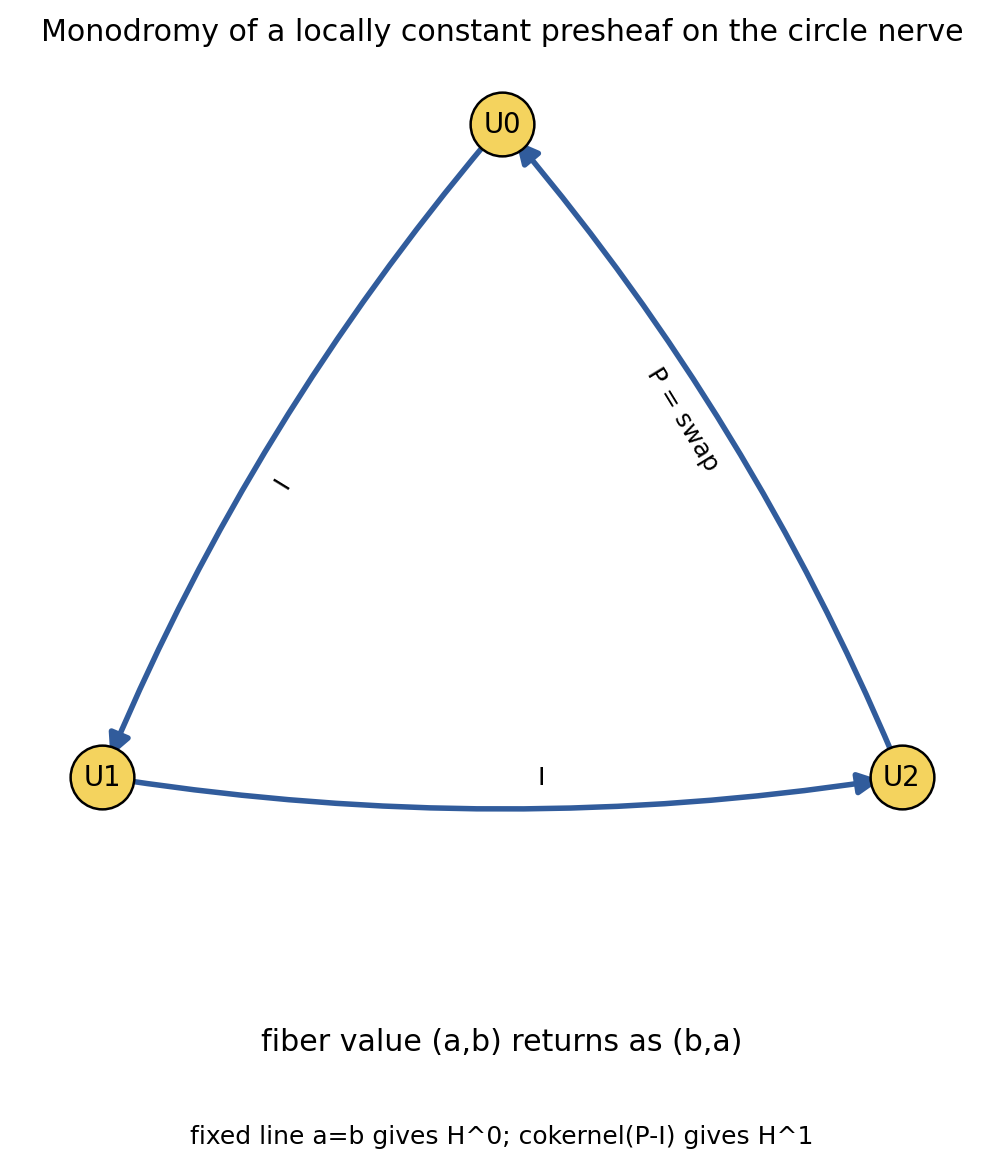

In [7]:
def local_system_circle_dims(P: sp.Matrix) -> dict:
    n = P.shape[0]
    A = P - sp.eye(n)
    rank = int(A.rank())
    return {"rank": n, "rank_P_minus_I": rank, "H0_dimension": n - rank, "H1_dimension": n - rank, "determinant": int(P.det()) if all(v.is_integer for v in P) else str(P.det())}

P_swap = sp.Matrix([[0, 1], [1, 0]])
P_sign = sp.Matrix([[-1]])
P_trivial = sp.Matrix([[1]])
swap_dims = local_system_circle_dims(P_swap)
sign_dims = local_system_circle_dims(P_sign)
trivial_dims = local_system_circle_dims(P_trivial)
assert swap_dims["H0_dimension"] == 1 and swap_dims["H1_dimension"] == 1
assert sign_dims["H0_dimension"] == 0 and sign_dims["H1_dimension"] == 0
assert trivial_dims["H0_dimension"] == 1 and trivial_dims["H1_dimension"] == 1

A01 = sp.Matrix([[1, 1], [0, 1]])
A12 = sp.Matrix([[1, 0], [-1, 1]])
A20 = (A12 * A01).inv()
triangle_loop = sp.simplify(A20 * A12 * A01)
assert triangle_loop == sp.eye(2)

fig, ax = plt.subplots(figsize=(8.2, 5.8))
base_pos = {0: np.array([0.0, 1.0]), 1: np.array([-0.95, -0.55]), 2: np.array([0.95, -0.55])}
base_graph = nx.DiGraph()
base_graph.add_edges_from([(0, 1), (1, 2), (2, 0)])
nx.draw_networkx_edges(base_graph, base_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=2.2, edge_color="#315c9c", connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(base_graph, base_pos, ax=ax, node_size=650, node_color="#f4d35e", edgecolors="black")
nx.draw_networkx_labels(base_graph, base_pos, labels={i: f"U{i}" for i in base_pos}, ax=ax, font_size=11)
edge_labels = {(0, 1): "I", (1, 2): "I", (2, 0): "P = swap"}
nx.draw_networkx_edge_labels(base_graph, base_pos, edge_labels=edge_labels, ax=ax, font_size=10, label_pos=0.55)
ax.text(0, -1.2, "fiber value (a,b) returns as (b,a)", ha="center", fontsize=12)
ax.text(0, -1.42, "fixed line a=b gives H^0; cokernel(P-I) gives H^1", ha="center", fontsize=10)
ax.set_title("Monodromy of a locally constant presheaf on the circle nerve")
ax.set_aspect("equal")
ax.axis("off")
monodromy_path = FIGURES / "monodromy-local-system-loop.png"
save_matplotlib(fig, monodromy_path, dpi=180)
plt.close(fig)

monodromy_check = {"swap_matrix": [[int(x) for x in row] for row in P_swap.tolist()], "swap_local_system_dimensions": swap_dims, "sign_local_system_dimensions_over_R": sign_dims, "trivial_rank_one_dimensions": trivial_dims, "bounding_triangle_loop_product": [[int(x) for x in row] for row in triangle_loop.tolist()], "triangle_loop_is_identity": triangle_loop == sp.eye(2)}
monodromy_check_path = CHECKS / "monodromy-local-system-checks.json"
save_json(monodromy_check, monodromy_check_path)
ARTIFACTS["monodromy_figure"] = monodromy_path
ARTIFACTS["monodromy_check"] = monodromy_check_path
CHECK_DATA["monodromy"] = monodromy_check
display_artifact(monodromy_path, width=760)


## 6. Sphere Bundles: Orientation, Euler Class, and Local Degree

For a sphere bundle, the first obstruction is orientability: local top cohomology generators on fibers must agree on overlaps as cohomology classes. If that succeeds, the double complex asks whether the local fiber-volume class can be extended diagonally downward to a total cocycle. The last unclosed term is a Cech cocycle on the base. Its de Rham image is the Euler class.

When the Euler class vanishes, the angular form can be made closed and Leray-Hirsch applies. When it does not vanish, the obstruction can be measured geometrically. For the unit tangent bundle of `S^2`, a vector field with one isolated singularity of local degree `2` gives Euler number `2`, matching the Euler characteristic.


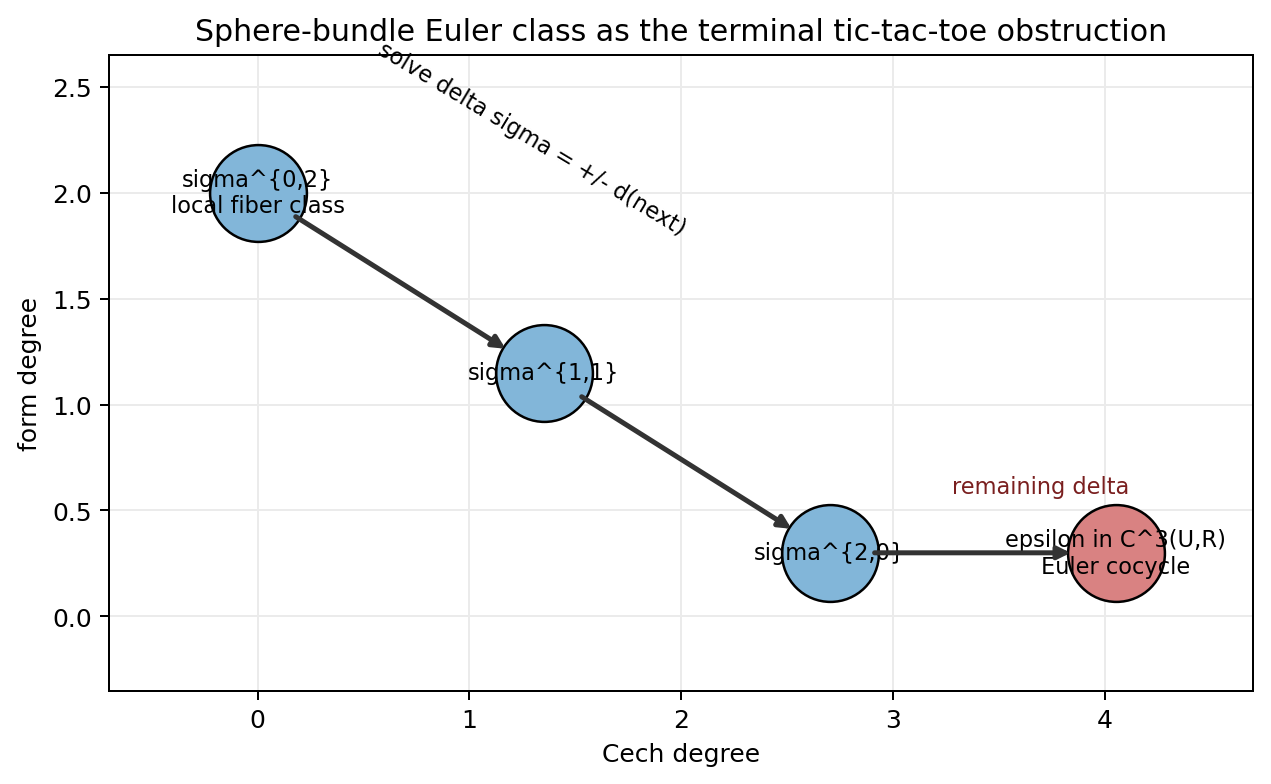

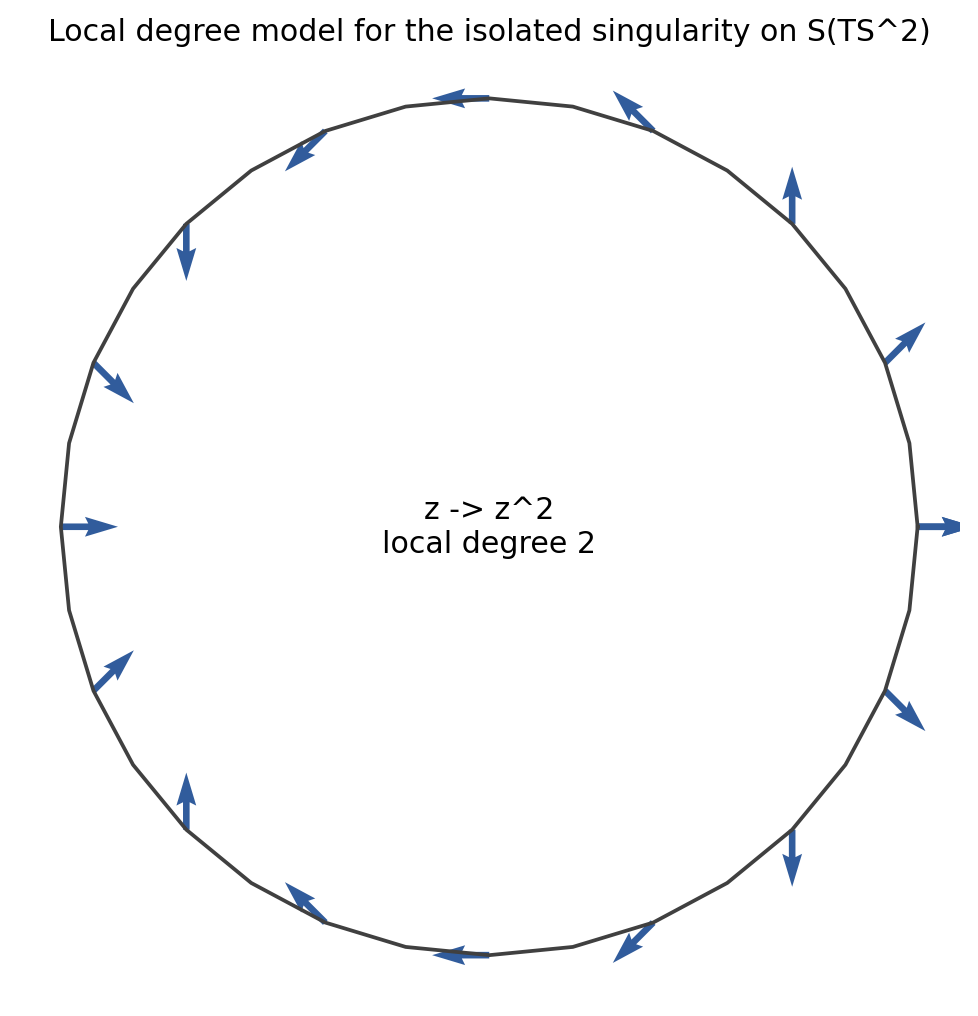

In [8]:
n = 2
fig, ax = plt.subplots(figsize=(8.2, 5.8))
coords = {(0, 2): (0, 2), (1, 1): (1.35, 1.15), (2, 0): (2.7, 0.3), (3, 0): (4.05, 0.3)}
labels = {(0, 2): "sigma^{0,2}\nlocal fiber class", (1, 1): "sigma^{1,1}", (2, 0): "sigma^{2,0}", (3, 0): "epsilon in C^3(U,R)\nEuler cocycle"}
for key, (x, y) in coords.items():
    color = "#d98282" if key == (3, 0) else "#82b6d9"
    ax.scatter(x, y, s=1500, color=color, edgecolor="black", zorder=3)
    ax.text(x, y, labels[key], ha="center", va="center", fontsize=9)
path_keys = [(0, 2), (1, 1), (2, 0), (3, 0)]
for a, b in zip(path_keys, path_keys[1:]):
    ax.annotate("", xy=coords[b], xytext=coords[a], arrowprops=dict(arrowstyle="-|>", lw=2, color="#333333", shrinkA=18, shrinkB=18))
ax.text(0.55, 1.8, "solve delta sigma = +/- d(next)", rotation=-31, fontsize=9)
ax.text(3.28, 0.58, "remaining delta", fontsize=9, color="#7a1f1f")
ax.set_xlim(-0.7, 4.7)
ax.set_ylim(-0.35, 2.65)
ax.set_xlabel("Cech degree")
ax.set_ylabel("form degree")
ax.set_title("Sphere-bundle Euler class as the terminal tic-tac-toe obstruction")
ax.grid(True, color="0.92")
ax.set_aspect("equal")
euler_obstruction_path = FIGURES / "sphere-bundle-euler-obstruction.png"
save_matplotlib(fig, euler_obstruction_path, dpi=180)
plt.close(fig)

phi = np.linspace(0, 2 * np.pi, 33)
points = np.column_stack([np.cos(phi), np.sin(phi)])
vec_angles = 2 * phi
vectors = np.column_stack([np.cos(vec_angles), np.sin(vec_angles)])
turning = float(np.unwrap(vec_angles)[-1] - np.unwrap(vec_angles)[0])
local_degree = int(round(turning / (2 * np.pi)))
chi_s2 = 2
assert local_degree == chi_s2 == 2

fig, ax = plt.subplots(figsize=(6.8, 6.8))
ax.plot(np.cos(phi), np.sin(phi), color="0.25", lw=1.5)
skip = 2
ax.quiver(points[::skip, 0], points[::skip, 1], vectors[::skip, 0], vectors[::skip, 1], angles="xy", scale_units="xy", scale=7.5, color="#315c9c", width=0.007)
ax.text(0, 0, "z -> z^2\nlocal degree 2", ha="center", va="center", fontsize=12)
ax.set_title("Local degree model for the isolated singularity on S(TS^2)")
ax.set_aspect("equal")
ax.axis("off")
local_degree_path = FIGURES / "euler-local-degree-s2.png"
save_matplotlib(fig, local_degree_path, dpi=180)
plt.close(fig)

sphere_euler_check = {"sphere_bundle_model_dimension_n": n, "obstruction_target": "C^{n+1}(U,R)", "local_degree_map": "z -> z^2 on boundary circle", "computed_local_degree": local_degree, "chi_S2": chi_s2, "euler_number_matches_chi": local_degree == chi_s2}
sphere_euler_check_path = CHECKS / "sphere-bundle-euler-checks.json"
save_json(sphere_euler_check, sphere_euler_check_path)
ARTIFACTS["euler_obstruction_figure"] = euler_obstruction_path
ARTIFACTS["local_degree_figure"] = local_degree_path
ARTIFACTS["sphere_euler_check"] = sphere_euler_check_path
CHECK_DATA["sphere_euler"] = sphere_euler_check
display_artifact(euler_obstruction_path, width=780)
display_artifact(local_degree_path, width=620)


## 7. Thom Isomorphism and Poincare Duality Revisited

The chapter revisits Thom isomorphism by replacing ordinary forms with forms compactly supported in the vertical direction of a vector bundle. The double complex is built from the inverse cover of the base. For a rank `n` bundle, compact vertical cohomology of a trivialized fiber is concentrated in degree `n`, so the tic-tac-toe lemma collapses the board to one row. If the bundle is orientable, the coefficient presheaf becomes the constant presheaf and the familiar degree shift appears.

The plotted cutoff is the computational part of the Thom class formula. A radial function is `-1` near the zero section and `0` outside a compact vertical neighborhood; its derivative supplies compact support. Pulling the Thom class back by the zero section returns the Euler class, which is why zero sets of transverse sections become Poincare dual to Euler classes.


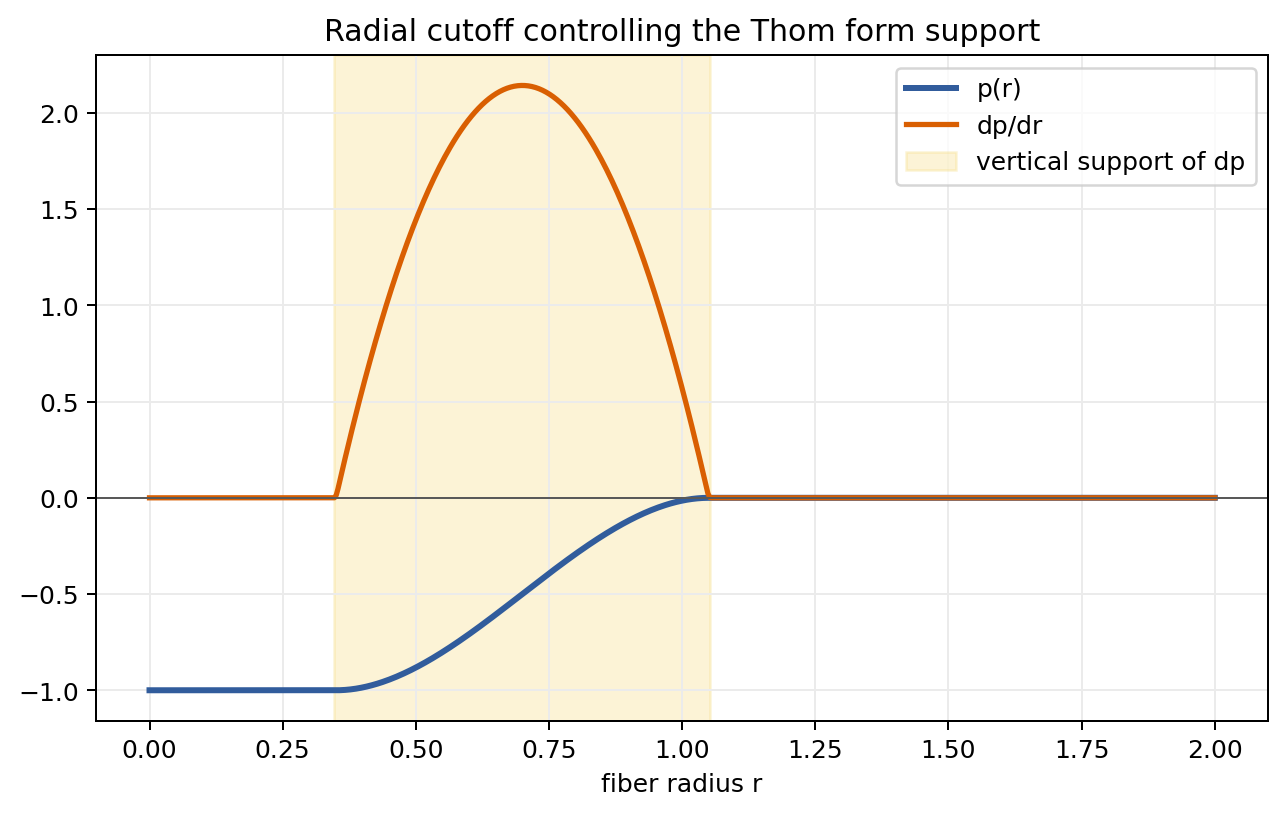

In [9]:
r = np.linspace(0, 2.0, 600)
a, b = 0.35, 1.05
t = np.clip((r - a) / (b - a), 0, 1)
smoothstep = 3 * t**2 - 2 * t**3
p_cutoff = -1 + smoothstep
dp = np.gradient(p_cutoff, r)
support_mask = np.abs(dp) > 1e-5
support_interval = [float(r[support_mask][0]), float(r[support_mask][-1])]
dp_integral = float(np.trapezoid(dp, r))
assert abs(dp_integral - 1.0) < 2e-3

e = sp.symbols("e")
s_pull_dp = sp.Integer(0)
s_pull_p = sp.Integer(-1)
s_pull_pi_e = e
s_pull_phi = sp.simplify(s_pull_dp - s_pull_p * s_pull_pi_e)
assert s_pull_phi == e

fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot(r, p_cutoff, lw=2.4, color="#315c9c", label="p(r)")
ax.plot(r, dp, lw=2.1, color="#d95f02", label="dp/dr")
ax.axvspan(support_interval[0], support_interval[1], color="#f4d35e", alpha=0.25, label="vertical support of dp")
ax.axhline(0, color="0.35", lw=0.8)
ax.set_xlabel("fiber radius r")
ax.set_title("Radial cutoff controlling the Thom form support")
ax.legend(loc="best")
ax.grid(True, color="0.92")
thom_path = FIGURES / "thom-cutoff-support.png"
save_matplotlib(fig, thom_path, dpi=180)
plt.close(fig)

thom_check = {"cutoff_value_near_zero": float(p_cutoff[0]), "cutoff_value_far_from_zero": float(p_cutoff[-1]), "dp_support_interval": support_interval, "integral_dp": dp_integral, "symbolic_zero_section_pullback_of_Thom_class": str(s_pull_phi), "expected_euler_class_symbol": str(e), "pullback_returns_euler_class": bool(s_pull_phi == e)}
thom_check_path = CHECKS / "thom-poincare-checks.json"
save_json(thom_check, thom_check_path)
ARTIFACTS["thom_figure"] = thom_path
ARTIFACTS["thom_check"] = thom_check_path
CHECK_DATA["thom"] = thom_check
display_artifact(thom_path, width=780)


## Applied Lab: Change the Cover or the Monodromy

The chapter's computations are stable enough to experiment with. The cell below exposes two small controls without requiring widgets: choose whether to fill the triangle in the circle nerve, and choose a monodromy matrix for a rank-one local system on the circle. Filling the triangle kills the 1-cycle. Changing monodromy from `+1` to `-1` kills both real local-system cohomology groups on the circle because `P-I` becomes invertible.

Try changing `fill_triangle` or `rank_one_monodromy` and rerun the cell. The result is a finite version of the chapter's two recurring messages: good-cover cohomology is controlled by nerve combinatorics, and locally constant coefficients are controlled by loop actions.


In [10]:
fill_triangle = False
rank_one_monodromy = -1  # try +1 for the constant rank-one presheaf

lab_max = [(0, 1), (1, 2), (0, 2)] + ([(0, 1, 2)] if fill_triangle else [])
lab_summary = betti_summary(lab_max, 2)
lab_P = sp.Matrix([[rank_one_monodromy]])
lab_local_system = local_system_circle_dims(lab_P)
lab_report = {
    "filled_triangle_in_nerve": fill_triangle,
    "nerve_betti": lab_summary["betti"],
    "rank_one_monodromy": rank_one_monodromy,
    "local_system_H0_dim": lab_local_system["H0_dimension"],
    "local_system_H1_dim": lab_local_system["H1_dimension"],
}
lab_report


{'filled_triangle_in_nerve': False,
 'nerve_betti': [1, 1, 0],
 'rank_one_monodromy': -1,
 'local_system_H0_dim': 0,
 'local_system_H1_dim': 0}

## Final Sanity Checks

These checks assert the notebook's mathematical and artifact contract rather than only checking that code ran. They verify exact identities, computed Betti numbers, monodromy ranks, Euler/local-degree data, Thom cutoff behavior, and the existence and nonzero size of generated artifacts.


In [11]:
# final_sanity
required_artifacts = [
    ARTIFACTS["routing_table"],
    ARTIFACTS["total_sign_check"],
    ARTIFACTS["total_complex_html"],
    ARTIFACTS["total_complex_static"],
    ARTIFACTS["proof_map"],
    ARTIFACTS["proof_map_check"],
    ARTIFACTS["nerve_figure"],
    ARTIFACTS["nerve_rank_table"],
    ARTIFACTS["nerve_check"],
    ARTIFACTS["collating_figure"],
    ARTIFACTS["collating_check"],
    ARTIFACTS["monodromy_figure"],
    ARTIFACTS["monodromy_check"],
    ARTIFACTS["euler_obstruction_figure"],
    ARTIFACTS["local_degree_figure"],
    ARTIFACTS["sphere_euler_check"],
    ARTIFACTS["thom_figure"],
    ARTIFACTS["thom_check"],
]
assert_artifacts(required_artifacts, min_bytes=80)

assert CHECK_DATA["total_sign_check"]["signed_D_squared_zero"] is True
assert CHECK_DATA["total_sign_check"]["naive_nonzero_entries_in_D_squared"] > 0
assert CHECK_DATA["nerve"]["circle"]["betti_exact"][:2] == [1, 1]
assert CHECK_DATA["nerve"]["sphere"]["betti_exact"][:3] == [1, 0, 1]
assert CHECK_DATA["collating"]["eta_is_coboundary"] is False
assert abs(CHECK_DATA["collating"]["collated_density_period"] - 1.0) < 5e-4
assert CHECK_DATA["monodromy"]["swap_local_system_dimensions"]["H0_dimension"] == 1
assert CHECK_DATA["monodromy"]["swap_local_system_dimensions"]["H1_dimension"] == 1
assert CHECK_DATA["monodromy"]["triangle_loop_is_identity"] is True
assert CHECK_DATA["sphere_euler"]["euler_number_matches_chi"] is True
assert CHECK_DATA["thom"]["pullback_returns_euler_class"] is True

final_summary = {
    "notebook": "chapter-02-the-cech-de-rham-complex/02-the-cech-de-rham-complex.ipynb",
    "source_span": SOURCE_SPAN,
    "artifact_count": len(required_artifacts),
    "artifacts": [rel(path) for path in required_artifacts],
    "core_checks": {
        "signed_total_differential_squared_zero": True,
        "circle_nerve_betti": CHECK_DATA["nerve"]["circle"]["betti_exact"],
        "sphere_nerve_betti": CHECK_DATA["nerve"]["sphere"]["betti_exact"],
        "circle_collated_period": CHECK_DATA["collating"]["collated_density_period"],
        "swap_monodromy_H_dims": [CHECK_DATA["monodromy"]["swap_local_system_dimensions"]["H0_dimension"], CHECK_DATA["monodromy"]["swap_local_system_dimensions"]["H1_dimension"]],
        "S2_local_degree": CHECK_DATA["sphere_euler"]["computed_local_degree"],
        "thom_pullback": CHECK_DATA["thom"]["symbolic_zero_section_pullback_of_Thom_class"],
    },
}
final_summary_path = CHECKS / "final-sanity-summary.json"
save_json(final_summary, final_summary_path)
assert_artifacts([final_summary_path], min_bytes=80)
ARTIFACTS["final_summary"] = final_summary_path

Markdown("All final sanity checks passed. Generated artifact manifest: `" + rel(final_summary_path) + "`.")


All final sanity checks passed. Generated artifact manifest: `artifacts/chapter-02-the-cech-de-rham-complex/checks/final-sanity-summary.json`.

## Takeaways

- The generalized Mayer-Vietoris principle is a total-complex statement: exact Cech rows let a cocycle be moved to the global-form column.
- A good cover adds exact augmented columns, so the de Rham computation becomes the combinatorics of the nerve.
- The collating formula is the constructive inverse direction: it turns a Cech cocycle into a global de Rham representative using a partition of unity.
- Sphere bundles reuse the same board. Orientability starts the diagonal extension; the Euler class is the terminal obstruction to closing it.
- Thom isomorphism and Poincare duality are compact-support versions of the tic-tac-toe lemma.
- Monodromy is the failure mode for locally constant presheaves: local constancy becomes actual constancy only when nerve loops act trivially.
